# Crop Prediction Model Evaluation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('datasets/newdataset.csv')
print(f"Dataset shape: {df.shape}\n")
df.head()

Dataset shape: (100, 1)



,field_id\tland\ttemperature\thumidity\trainfall\tbudget\tsoil_type\tph\twater_requirement\tsuggested_crop\tsuggested_fertilizers\tsuggested_pesticides\tpotential_diseases\tnitrogen\tphosphorus\tpotassium\testimated_yield
0,1\t10\t25\t60\t500\t5000\tSandy\t6.5\t20\tRice...
1,2\t15\t28\t55\t600\t7000\tClay\t7\t25\tWheat\t...
2,3\t20\t22\t65\t450\t6000\tLoam\t6\t18\tCorn\tA...
3,4\t12\t27\t58\t550\t6500\tSandy\t6.8\t22\tRice...
4,5\t18\t24\t62\t480\t6200\tClay\t7.2\t24\tSoybe...


## Feature Engineering

In [ ]:
def create_features(df):
    # First, check and fix column names by extracting from the tab-delimited data
    if len(df.columns) == 1:
        column_name = df.columns[0]
        df = df[column_name].str.split('\t', expand=True)
        df.columns = [
            'field_id', 'land', 'temperature', 'humidity', 'rainfall',
            'budget', 'soil_type', 'ph', 'water_requirement',
            'suggested_crop', 'suggested_fertilizers', 'suggested_pesticides',
            'potential_diseases', 'nitrogen', 'phosphorus', 'potassium',
            'estimated_yield'
        ]
    
    # Convert numeric columns
    numeric_cols = ['nitrogen', 'phosphorus', 'potassium', 'ph', 
                   'rainfall', 'water_requirement', 'temperature', 
                   'humidity', 'land', 'budget']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate features with error handling
    df['npk_ratio'] = ((df['nitrogen'] * df['phosphorus'] * df['potassium']).clip(lower=1)) ** (1/3)
    df['water_stress'] = (df['rainfall'] / df['water_requirement']).clip(lower=0, upper=2)
    df['soil_health'] = (
        10 - abs(df['ph'] - 7).clip(lower=0, upper=7) + 
        (df['nitrogen']/150).clip(lower=0, upper=1) + 
        (df['phosphorus']/75).clip(lower=0, upper=1) + 
        (df['potassium']/100).clip(lower=0, upper=1)
    ).clip(lower=0, upper=10)
    df['climate_index'] = (
        abs(df['temperature'] - 25)/10 + 
        abs(df['humidity'] - 60)/20
    ).clip(lower=0, upper=1)
    
    return df

try:
    df = create_features(df)
    print("Features created successfully")
    print("\nFeature statistics:")
    print(df[['npk_ratio', 'water_stress', 'soil_health', 'climate_index']].describe())
except Exception as e:
    print(f"Error creating features: {str(e)}")

Features created successfully

Feature statistics:
        npk_ratio  water_stress  soil_health  climate_index
count  100.000000         100.0        100.0     100.000000
mean    98.939746           2.0         10.0       0.309500
std      5.952258           0.0          0.0       0.197164
min     86.534974           2.0         10.0       0.000000
25%     93.956749           2.0         10.0       0.200000
50%     97.814135           2.0         10.0       0.250000
75%    103.308545           2.0         10.0       0.512500
max    109.086876           2.0         10.0       0.600000


## Model Training & Evaluation

In [ ]:
def process_data(df):
    # Remove classes with too few samples (minimum 2)
    class_counts = df['suggested_crop'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    df = df[df['suggested_crop'].isin(valid_classes)]
    
    df['soil_type_encoded'] = (df['soil_type'].str.lower() == 'clay').astype(int)
    
    features = [
        'temperature', 'humidity', 'rainfall', 'ph',
        'nitrogen', 'phosphorus', 'potassium',
        'land', 'budget', 'soil_type_encoded',
        'npk_ratio', 'water_stress', 'soil_health', 'climate_index'
    ]
    
    X = df[features]
    y = df['suggested_crop']
    
    # Print class distribution
    print("Class distribution before SMOTE:")
    print(y.value_counts())
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Use SMOTE with k_neighbors based on smallest class size
    k_neighbors = min(5, min(class_counts[valid_classes]) - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    
    print("\nClass distribution after SMOTE:")
    print(pd.Series(y_train_balanced).value_counts())
    
    return X_train_balanced, X_test_scaled, y_train_balanced, y_test, scaler

try:
    X_train_balanced, X_test_scaled, y_train_balanced, y_test, scaler = process_data(df)
    print("\nData processed successfully")
except Exception as e:
    print(f"Error processing data: {str(e)}")

Class distribution before SMOTE:
suggested_crop
Tomatoes      9
Onions        9
Soybean       8
Barley        8
Potatoes      8
Peanuts       8
Sugarcane     8
Cotton        8
Sunflowers    8
Oats          8
Carrots       7
Beans         7
Rice          2
Name: count, dtype: int64

Class distribution after SMOTE:
suggested_crop
Sugarcane     7
Potatoes      7
Soybean       7
Carrots       7
Oats          7
Barley        7
Onions        7
Cotton        7
Sunflowers    7
Tomatoes      7
Beans         7
Rice          7
Peanuts       7
Name: count, dtype: int64

Data processed successfully


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_balanced, y_train_balanced)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.9894736842105264


Classification Report:
              precision    recall  f1-score   support

      Barley       1.00      1.00      1.00         2
       Beans       1.00      1.00      1.00         1
     Carrots       1.00      1.00      1.00         1
      Cotton       1.00      1.00      1.00         1
        Oats       1.00      1.00      1.00         2
      Onions       1.00      1.00      1.00         2
     Peanuts       1.00      1.00      1.00         2
    Potatoes       1.00      1.00      1.00         2
     Soybean       1.00      1.00      1.00         2
   Sugarcane       1.00      1.00      1.00         2
  Sunflowers       1.00      1.00      1.00         1
    Tomatoes       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



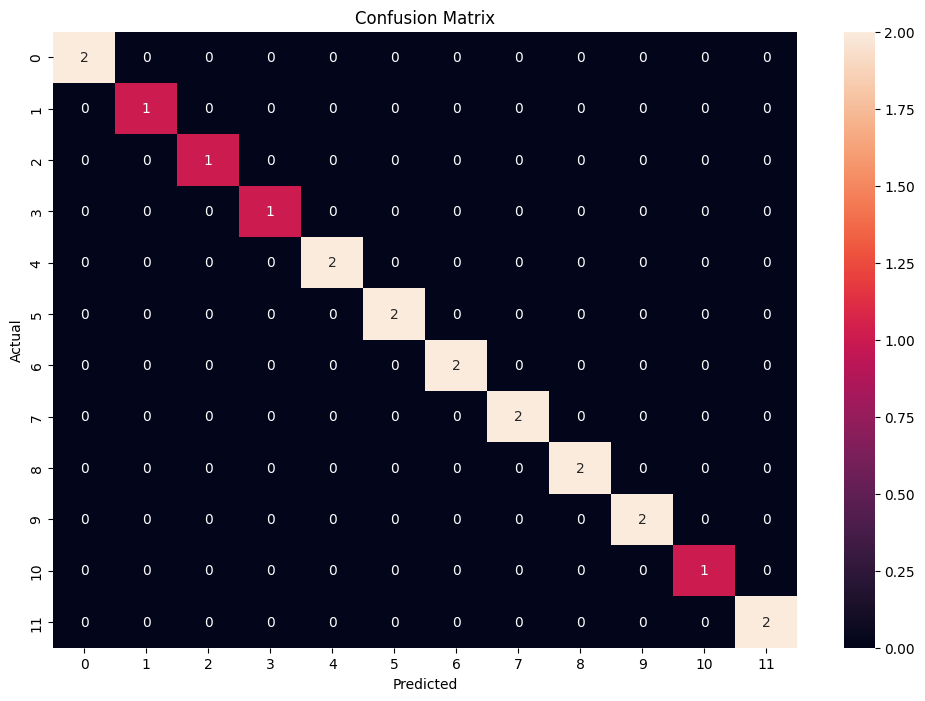

In [ ]:
y_pred = best_model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

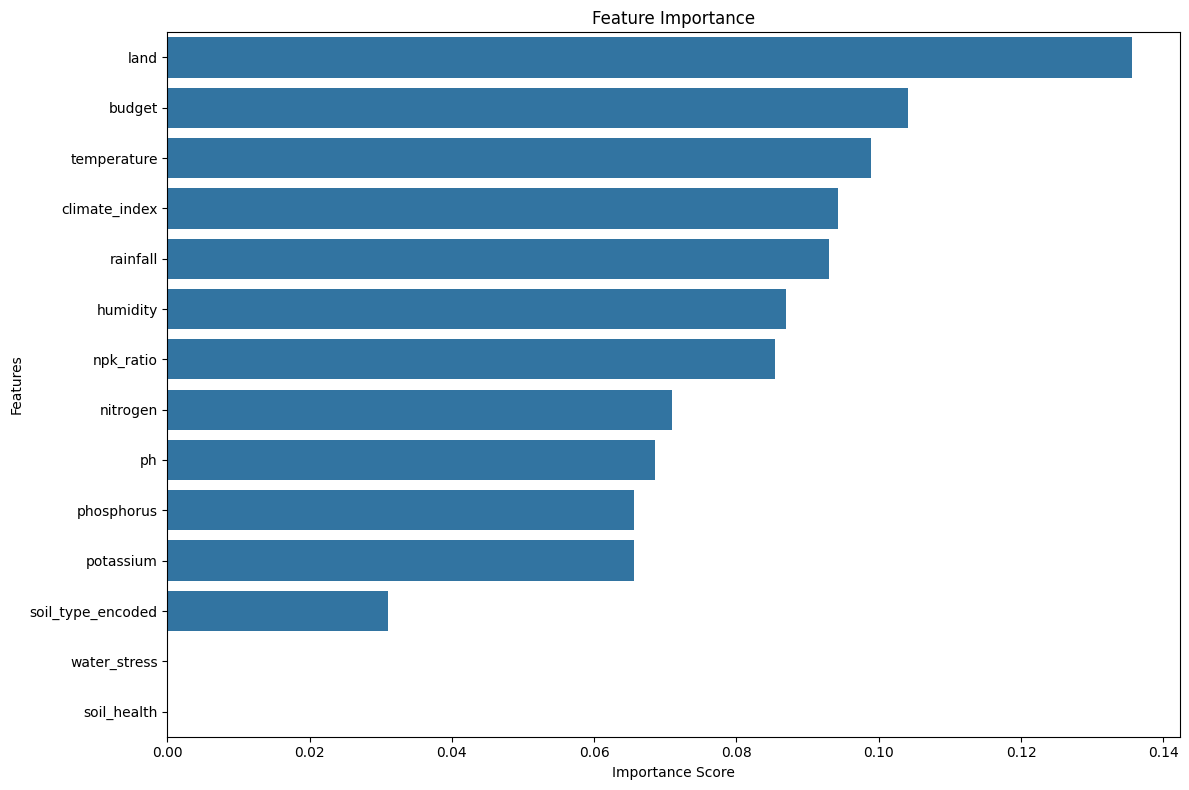


Feature Importance Scores:
          feature  importance
             land    0.135556
           budget    0.104114
      temperature    0.098893
    climate_index    0.094238
         rainfall    0.093056
         humidity    0.086905
        npk_ratio    0.085480
         nitrogen    0.070975
               ph    0.068589
       phosphorus    0.065612
        potassium    0.065568
soil_type_encoded    0.031015
     water_stress    0.000000
      soil_health    0.000000


In [ ]:
def plot_feature_importance(model, feature_names):
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    importance = importance.sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance, x='importance', y='feature')
    plt.title('Feature Importance')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

    return importance

# Feature names in correct order
feature_names = [
    'temperature', 'humidity', 'rainfall', 'ph',
    'nitrogen', 'phosphorus', 'potassium',
    'land', 'budget', 'soil_type_encoded',
    'npk_ratio', 'water_stress', 'soil_health', 'climate_index'
]

importance_df = plot_feature_importance(best_model, feature_names)
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

In [ ]:
print("Cross-validation scores:")
cv_scores = cross_val_score(best_model, X_train_balanced, y_train_balanced, cv=5)
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-validation scores:
Mean CV Score: 0.9895 (+/- 0.0421)
